In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Count'>

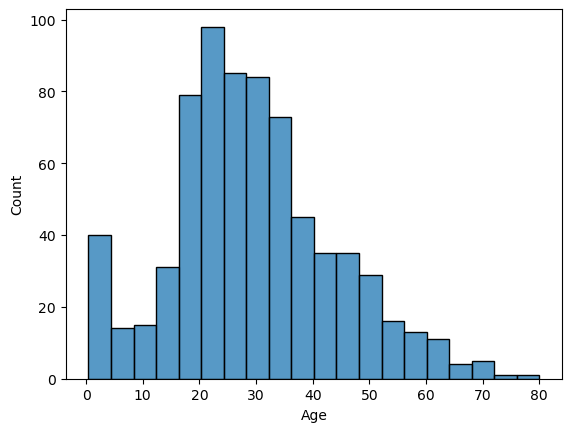

In [42]:
sns.histplot(df["Age"])  # Age is right skewed

In [43]:
print(df.isnull().sum())  # Since cabin does not contribute to our outcome and so many values of it are unkown so its better to drop the Cabin column
                          # NaN age values are filled my average age values
df.shape

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


(891, 12)

In [ ]:
Median = df["Age"].median()   # Age should be filled with median value
df["Age"] = df["Age"].fillna(Median)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode())

df = df.drop(columns="Cabin")

In [45]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [22]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# EDA

<Axes: xlabel='count', ylabel='Sex'>

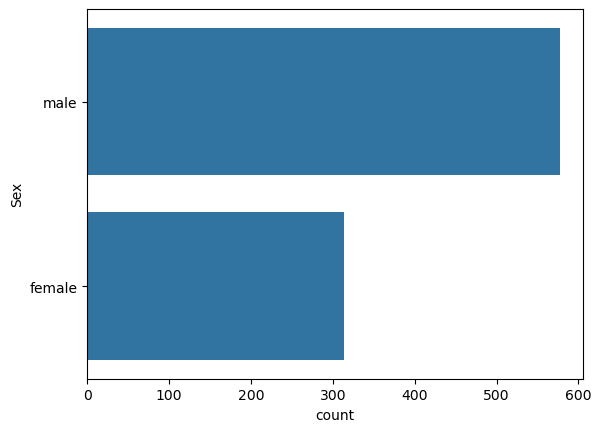

In [31]:
# sns.histplot(df["Age"])

sns.countplot(df["Sex"]) 

# There are more no.of Males than females 

<Axes: xlabel='Sex', ylabel='count'>

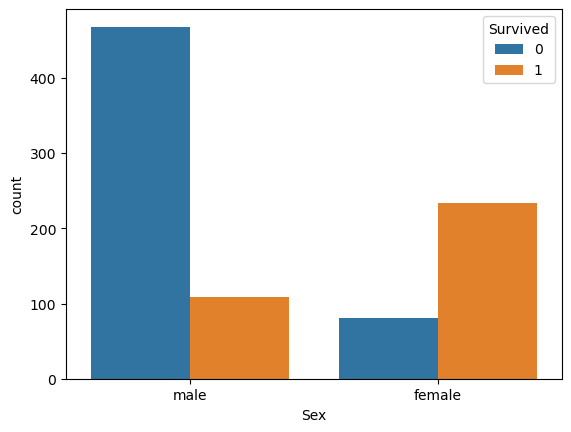

In [ ]:
sns.countplot(
    data = df,
    x = "Sex",
    hue = "Survived"
)

# More females are survived than male 

<Axes: xlabel='Pclass', ylabel='count'>

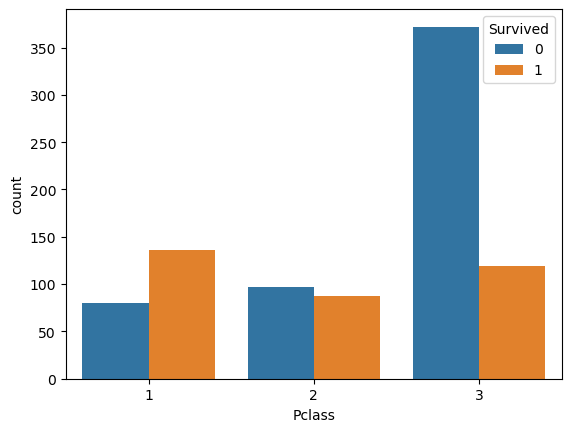

In [33]:
sns.countplot(
    data = df,
    x = "Pclass",
    hue = "Survived"
)

<Axes: >

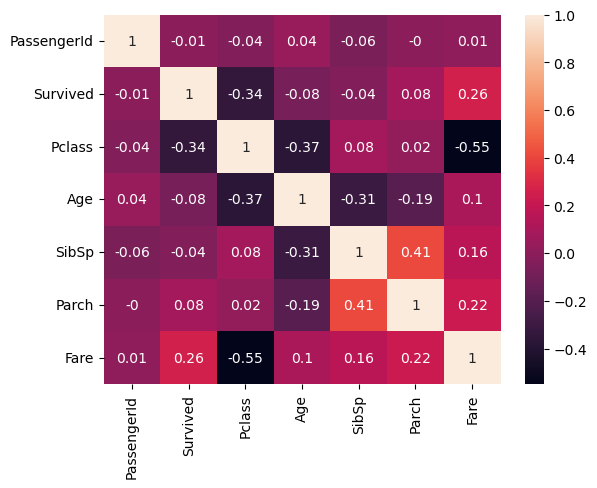

In [37]:
sns.heatmap(
    df.corr(numeric_only=True).round(decimals=2),
    annot = True
    
)

==> Conclusion

-> Females have higher survival rate

-> Survival rate of 1st class passangers is more & lower for 3rd class

-> From correlation Heatmap , there is decent relationship between Survival Rate and Fare && Weak Relation betweek Age and Survival rate


In [48]:
# There is nothing to do with passenger ID , Names , Cabin , Ticket : They can dropped

df = df.drop(columns = ["PassengerId","Name","Ticket"]) 

# Model Selection , Training and Evaluation

In [74]:
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,recall_score,precision_score

In [75]:
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

In [76]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [77]:
X = df.drop(columns = "Survived")
y = df["Survived"]

In [78]:
X_train , X_test, y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state = 42
)

# Using Standard Scaler

In [79]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
model = LogisticRegression(max_iter=500 , solver = "liblinear")
model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=500, solver='liblinear')

In [101]:
y_pred = model.predict(X_test_scaled)

In [107]:
print(f"Accuracy : {accuracy_score(y_test,y_pred)*100} %")
print(f"Recall Score : {recall_score(y_test,y_pred)*100} %")
print("Precision ",precision_score(y_test,y_pred)*100,"%")
print("confusion_matrix :")
print(f"{confusion_matrix(y_test,y_pred)}")
print("classification_report :\n")
print(f"{classification_report(y_test,y_pred)}")

Accuracy : 81.00558659217877 %
Recall Score : 74.32432432432432 %
Precision  78.57142857142857 %
confusion_matrix :
[[90 15]
 [19 55]]
classification_report :

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# SVM

In [103]:
from sklearn.svm import SVC

model1 = SVC()

In [104]:
model1.fit(X_train_scaled,y_train)

SVC()

In [105]:
y_pred1 = model1.predict(X_test_scaled)

In [108]:
print(f"Accuracy : {accuracy_score(y_test,y_pred1)*100} %")
print(f"Recall Score : {recall_score(y_test,y_pred1)*100} %")
print("Precision ",precision_score(y_test,y_pred1)*100,"%")
print("confusion_matrix :")
print(f"{confusion_matrix(y_test,y_pred1)}")
print("classification_report :\n")
print(f"{classification_report(y_test,y_pred1)}")

Accuracy : 81.56424581005587 %
Recall Score : 71.62162162162163 %
Precision  81.53846153846153 %
confusion_matrix :
[[93 12]
 [21 53]]
classification_report :

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.72      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179

